# Recap of week 1 Topics

# Q&A of coin flip homework

# Pauli gates

In the first exercise of week 1, we asked you to play around with some single qubit gates. Three of these were the $X$, $Y$, and $Z$ gates, known as the Pauli gates. These are simplest single qubit gates and correspond to 180° rotations around their respective axes.

$$
X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}, \quad
Y = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix}, \quad
Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}
$$

Another way to think of these gates is how they affect the computational basis states (since this is typically the basis we measure in):

$$
\text{X: } 
\ket{0} \xrightarrow{X} \ket{1}, \quad
\ket{1} \xrightarrow{X} \ket{0}
$$

$$
\text{Y: } 
\ket{0} \xrightarrow{Y} i\ket{1}, \quad
\ket{1} \xrightarrow{Y} -i\ket{0}
$$

$$
\text{Z: } 
\ket{0} \xrightarrow{Z} \ket{0}, \quad
\ket{1} \xrightarrow{Z} -\ket{1}
$$

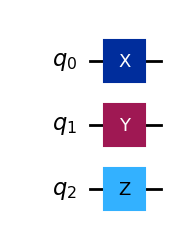

In [11]:
from qiskit.circuit import QuantumCircuit

qc = QuantumCircuit(3)

qc.x(0)
qc.y(1)
qc.z(2)

qc.draw("mpl")

In [2]:
for inst in qc.data:
    print(inst.operation.definition)

   ┌──────────┐
q: ┤ U(π,0,π) ├
   └──────────┘
   ┌──────────────┐
q: ┤ U(π,π/2,π/2) ├
   └──────────────┘
   ┌──────┐
q: ┤ P(π) ├
   └──────┘


### (Any idea why Z is unique among the three Pauli gates here? Look at how it affects the computational basis states again.)

### But we are not limited to only rotating 180 degrees (pi radians) in x, y, and z. We can choose the amount we rotate in each axis with the Rx, Ry, Rz gates (Rotate x, Rotate y, Rotate z). 

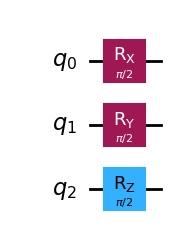

In [ ]:
from qiskit.circuit import QuantumCircuit
import numpy as np

qc = QuantumCircuit(3)

qc.rx(theta=np.pi/2, qubit=0)
qc.ry(theta=np.pi/2, qubit=1)
qc.rz(phi=np.pi/2, qubit=2)

qc.draw("mpl")

---
---

# Multiple qubits, Superposition and Entanglement

---

## 1. Two qubits, no superposition, no entanglement

$$
\ket{00} = \ket{0} \otimes \ket{0} = \begin{pmatrix}
1 \\ 0 \\ 0 \\ 0
\end{pmatrix} = 1\ket{00} + 0\ket{01} + 0\ket{10} + 0\ket{11}
$$

[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
{np.str_('00'): np.float64(1.0)}


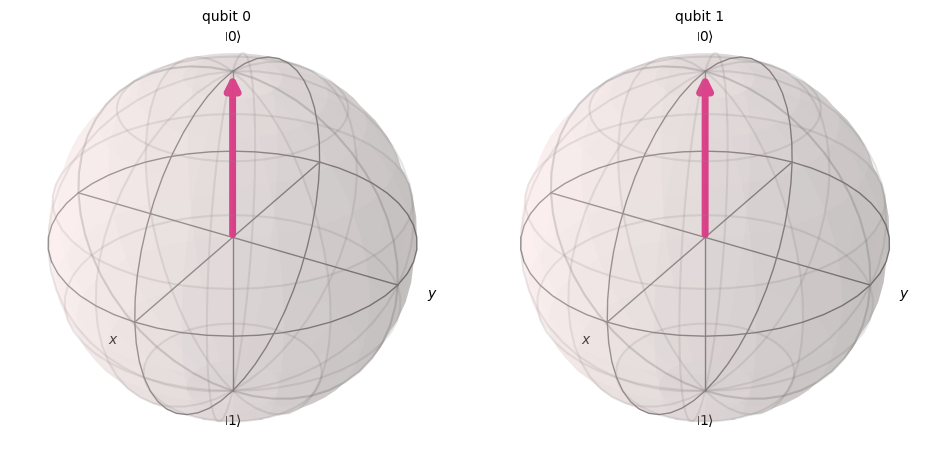

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

qc = QuantumCircuit(2) # initialise a quantum circuit with two qubits in the 0 state
state = Statevector.from_instruction(qc)

print(state.data)
print(state.probabilities_dict())

plot_bloch_multivector(state)

## 2. Two qubits, independent superposition, no entanglement

$$ 
(H \otimes I)\ket{00} = \dfrac{1}{\sqrt{2}} (\ket{00} + \ket{10}) = 
\dfrac{1}{\sqrt{2}} 
\begin{pmatrix}
1 \\0 \\ 1 \\ 0
\end{pmatrix}
$$

Here we applied the H gate on the left qubit, and identity on the right qubit. $(H \otimes I)\ket{00}$ is shorthand for $H\ket{0}\otimes I \ket{0}$

The Identity Gate leaves the Qubit unchanged. So the right qubit is still in the state $\ket{0}$ and the left qubit is in the superposition state $\dfrac{1}{\sqrt{2}} (\ket{0} + \ket{1})$ 

[0.70710678+0.j 0.70710678+0.j 0.        +0.j 0.        +0.j]
{np.str_('00'): np.float64(0.4999999999999999),
 np.str_('01'): np.float64(0.4999999999999999)}


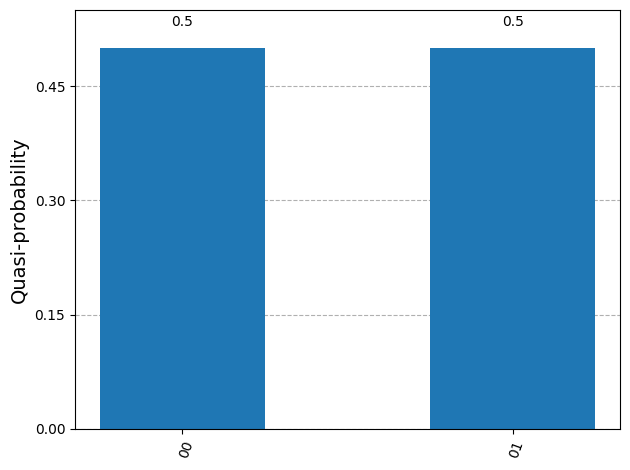

In [3]:
from qiskit.visualization import plot_histogram
import pprint

qc = QuantumCircuit(2)
qc.h(0)

state = Statevector.from_instruction(qc)
print(state.data)
pprint.pp(state.probabilities_dict())
plot_histogram(state.probabilities_dict())

## 3. Equal superposition across all states, still no entanglement

### $ (H \otimes H)\ket{00} = \dfrac{1}{2} (\ket{00} + \ket{01}+\ket{10} + \ket{11}) = \dfrac{1}{2} \begin{pmatrix} 1 & 1 & 1 & 1 \end{pmatrix}$

[0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]
{np.str_('00'): np.float64(0.2499999999999999),
 np.str_('01'): np.float64(0.2499999999999999),
 np.str_('10'): np.float64(0.2499999999999999),
 np.str_('11'): np.float64(0.2499999999999999)}


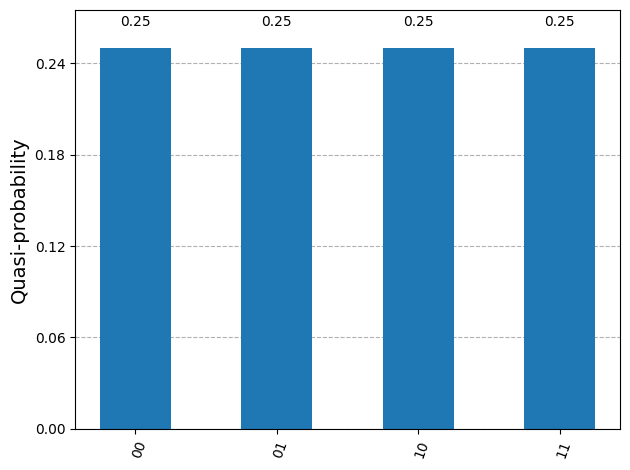

In [4]:
qc = QuantumCircuit(2)
qc.h(0)
qc.h(1)

state = Statevector.from_instruction(qc)
print(state.data)
pprint.pp(state.probabilities_dict())
plot_histogram(state.probabilities_dict())

## Generalised uniform superposition state

## $H^{\otimes n} \lvert 0 \ldots 0 \rangle = \frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n - 1} \lvert x \rangle = \ket{+}^{\otimes n}$

### Preparing the uniform superposition state is often step 1 of many quantum algorithms like Deutsch-Joza, Grover, QFT etc

### Why? It prepares the state in a uniform distribution of all states

{np.str_('00000'): np.float64(0.031249999999999976),
 np.str_('00001'): np.float64(0.031249999999999976),
 np.str_('00010'): np.float64(0.031249999999999976),
 np.str_('00011'): np.float64(0.031249999999999976),
 np.str_('00100'): np.float64(0.031249999999999976),
 np.str_('00101'): np.float64(0.031249999999999976),
 np.str_('00110'): np.float64(0.031249999999999976),
 np.str_('00111'): np.float64(0.031249999999999976),
 np.str_('01000'): np.float64(0.031249999999999976),
 np.str_('01001'): np.float64(0.031249999999999976),
 np.str_('01010'): np.float64(0.031249999999999976),
 np.str_('01011'): np.float64(0.031249999999999976),
 np.str_('01100'): np.float64(0.031249999999999976),
 np.str_('01101'): np.float64(0.031249999999999976),
 np.str_('01110'): np.float64(0.031249999999999976),
 np.str_('01111'): np.float64(0.031249999999999976),
 np.str_('10000'): np.float64(0.031249999999999976),
 np.str_('10001'): np.float64(0.031249999999999976),
 np.str_('10010'): np.float64(0.03124999999999

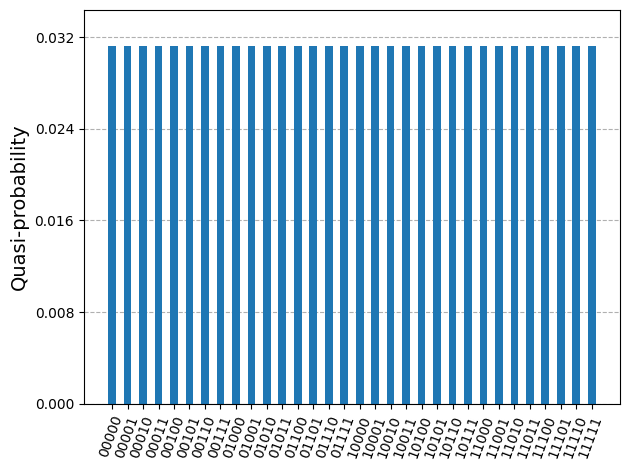

In [6]:
n = 5
qc = QuantumCircuit(n)

for i in range(n):
    qc.h(i)

# or if you want to be slick
# qc.h(range(n)) 

state = Statevector.from_instruction(qc)
pprint.pp(state.probabilities_dict())
plot_histogram(state.probabilities_dict(), bar_labels=False)

## 4. Entanglement

### To entangle qubits we need to introduce our first two qubit gate CNOT (Controlled-NOT)

### CNOT says "if our control qubit is in the $|1\rangle$ state, then apply NOT to our target qubit"

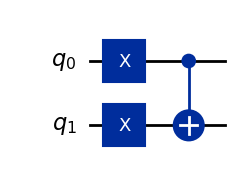

In [11]:
qc = QuantumCircuit(2)
qc.x(0)
qc.x(1)
qc.cx(control_qubit=0, target_qubit=1)
qc.draw("mpl")

{np.str_('01'): np.float64(1.0)}


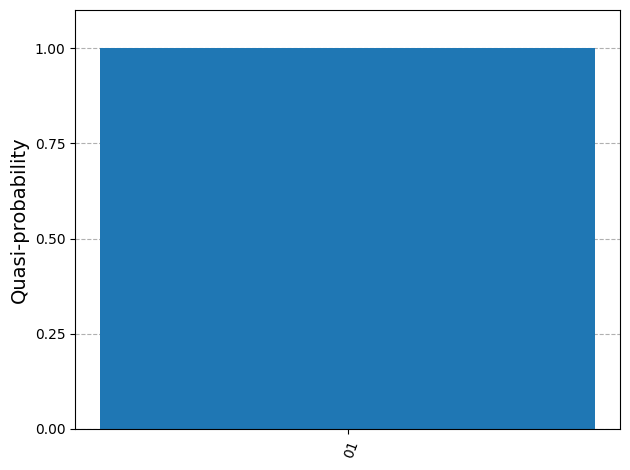

In [12]:
state = Statevector.from_instruction(qc)
pprint.pp(state.probabilities_dict())
plot_histogram(state.probabilities_dict(), bar_labels=False)

## Nothing happens because our control qubit was in the 0 state

## If we apply H to qubit 0 first and then CNOT we get:

## $ CNOT (H \otimes I)\ket{00} = \dfrac{1}{\sqrt{2}} (\ket{00} + \ket{11})$

Now we are really starting to step into some of the pecularities of quantum computing. We applied a Hadamard gate on qubit 0 which put it in the superposition state. Then we applied a controlled-NOT on qubit 1 with qubit 0 as the control qubit. But qubit 0 is in superposition? How does qubit 1 'know' what to turn into? Should it stay as 0 or negate into a 1? Is qubit 1 now in superposition as well as qubit 0? 

[0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]
{np.str_('00'): np.float64(0.4999999999999999),
 np.str_('11'): np.float64(0.4999999999999999)}


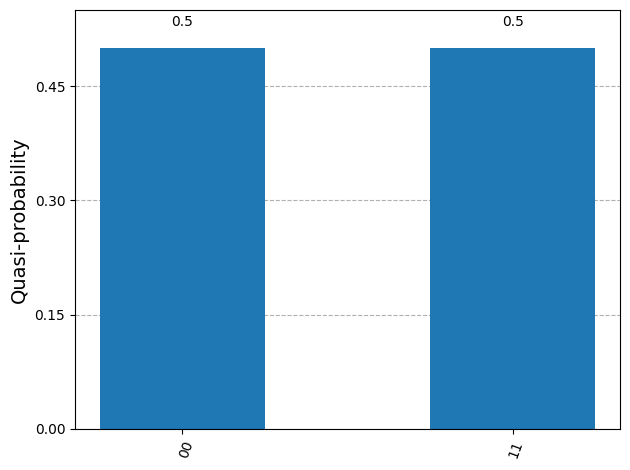

In [13]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(control_qubit=0, target_qubit=1)

state = Statevector.from_instruction(qc)
print(state.data)
pprint.pp(state.probabilities_dict())
plot_histogram(state.probabilities_dict())

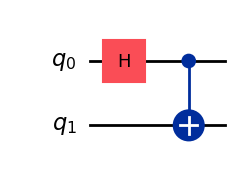

In [14]:
qc.draw(output='mpl')

# Exercise (10 mins):

There are four bell states (maximally entangled states). We have made the first one $\ket{\Phi^+}$. Can you make the other three?

### $\ket{\Phi^+} = \dfrac{1}{\sqrt{2}} (\ket{00} + \ket{11})$

### $\ket{\Phi^-} = \frac{1}{\sqrt{2}}\big(\ket{00} - \ket{11}\big)$

### $\ket{\Psi^+} = \frac{1}{\sqrt{2}}\big(\ket{01} + \ket{10}\big)$

### $\ket{\Psi^-} = \frac{1}{\sqrt{2}}\big(\ket{01} - \ket{10}\big)$

[ 0.        +0.j -0.70710678+0.j  0.70710678+0.j  0.        +0.j]
{np.str_('01'): np.float64(0.4999999999999999),
 np.str_('10'): np.float64(0.4999999999999999)}


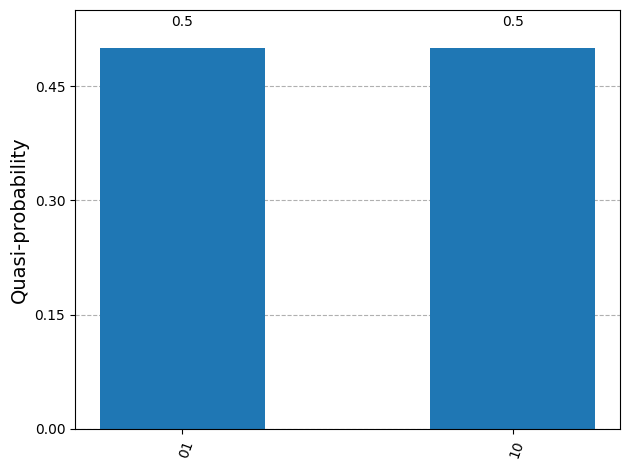

In [26]:
# Answer here

qc = QuantumCircuit(2)

qc.x(qubit=0)
qc.x(qubit=1)
qc.h(qubit=0)
qc.cx(control_qubit=0, target_qubit=1)

state = Statevector.from_instruction(qc)
print(state.data)
pprint.pp(state.probabilities_dict())
plot_histogram(state.probabilities_dict())

## Big takeaway: you need two-qubit gates to generate entanglement - typically people use the CNOT gate. 

---

## Measuring Entanglement

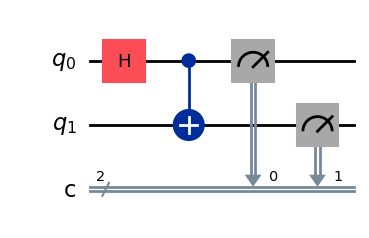

In [27]:
from qiskit_aer import AerSimulator

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)

qc.measure([0, 1], [0, 1]) # measure qubit(s) [0, 1] into classical bit(s) [0, 1] respectively
qc.draw(output='mpl')

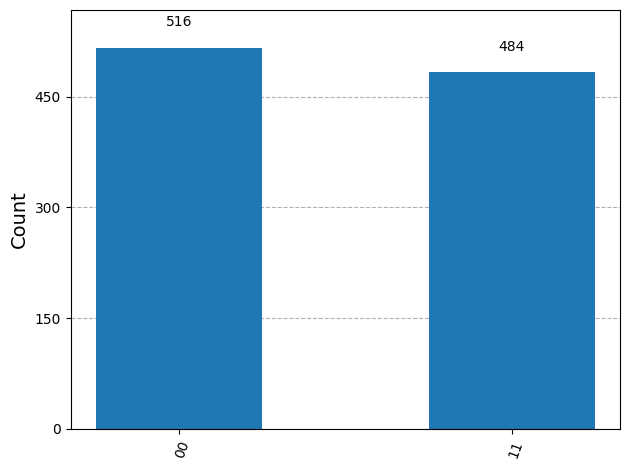

In [ ]:
sim = AerSimulator()
result = sim.run(qc, shots=1).result()
counts = result.get_counts()
plot_histogram(counts)

### Bonus: You can use Qiskit's inbuilt concurrence function to determine entanglement

In [31]:
from qiskit.quantum_info import concurrence

bell_state = QuantumCircuit(2)
bell_state.h(0)
bell_state.cx(0, 1)

print("Bell state concurrence:", concurrence(Statevector.from_circuit(bell_state)))

Bell state concurrence: 1.0000000000000002


---
---
# Appendix 

In this notebook we demonstrated how to prepare a few different entangled states, and talked a bit about what entanglement actually is - correlations between qubits. In the following appendix I show that correlation alone is not actually indicative of entanglement (indeed correlation exists in the classical realm) and I will demonstrate a full quantum experiment (using simulators) where I prove that we truly entangled two qubits. 

The procedure for this experiment goes as follows:

1. Apply the typical entangling procedure for two qubits (H on qubit 0 followed by CNOT between qubit 0 and 1).
2. Measure the correlation between our two qubits in the Z basis.
3. Repeat the entangling procedure and measurement in Z until we are satisfied that our two qubits are indeed correlated.
4. Repeat the entangling procedure again.
5. Rotate our measurement basis by applying a Hadamard on all two of our qubits just before measurement. *
6. Measure the correlation between our two qubits in what is now the X basis.
7. Repeat the entangling procedure and measurement in X until we are satisfied that our two qubits are still correlated even in this new basis.

If our system were classically correlated in some way then changing the basis of our measurement would break this correlation. For example if someone prepared a box of dice with all the 6s facing upwards you can be sure that all the 1s are facing downwards, but you can make no statement about which direction the other faces of each die is facing (this is a very loose analogy).

Since our system is correlated in a quantum way we find that it actually makes no difference what basis we measure in. When we say the two qubits are entangled, we literally mean there is no way to describe the state of one qubit without describing the other. Changing the basis in which we measure shouldn't have any effect on this. 

## Let's break entanglement down a bit more

### We will prepare a Bell state and measure the qubits individually.

In [62]:
# Step 1: prepare Bell state
# Bell state |Φ+> = (|00> + |11>)/√2
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

# Get the statevector
state = Statevector.from_instruction(qc)
print(state)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


In [61]:
# Step 2: Measure qubit 0 and collapse the state
outcome_0, state_after_0 = state.measure([0])
print("Qubit 0 measured:", outcome_0)
print("State after measuring qubit 0:", state_after_0)

# Step 3: Measure qubit 1
outcome_1, state_after_1 = state_after_0.measure([1])
print("Qubit 1 measured:", outcome_1)

Qubit 0 measured: 1
State after measuring qubit 0: Statevector([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))
Qubit 1 measured: 0


In [68]:
# Repeat for N shots to show correlation every time
shots = 10
for i in range(shots):
    outcome_0, state_after_0 = state.copy().measure([0])
    outcome_1, state_after_1 = state_after_0.measure([1])
    print(f"Run {i+1}: qubit0={outcome_0}, qubit1={outcome_1}")

Run 1: qubit0=0, qubit1=0
Run 2: qubit0=1, qubit1=1
Run 3: qubit0=0, qubit1=0
Run 4: qubit0=1, qubit1=1
Run 5: qubit0=1, qubit1=1
Run 6: qubit0=1, qubit1=1
Run 7: qubit0=1, qubit1=1
Run 8: qubit0=1, qubit1=1
Run 9: qubit0=1, qubit1=1
Run 10: qubit0=0, qubit1=0


## If we do the same experiment with a product state we see no correlation between the qubits

In [69]:
# Product state |0> ⊗ (|0> + |1>)/√2
state_product = Statevector.from_label('0')
state_product = state_product.tensor(Statevector([1/2**0.5, 1/2**0.5]))

# Stepwise measurement
shots = 10
for i in range(shots):
    outcome_0, state_after_0 = state_product.copy().measure([0])
    outcome_1, state_after_1 = state_after_0.measure([1])
    print(f"Run {i+1}: qubit0={outcome_0}, qubit1={outcome_1}")

Run 1: qubit0=1, qubit1=0
Run 2: qubit0=0, qubit1=0
Run 3: qubit0=0, qubit1=0
Run 4: qubit0=0, qubit1=0
Run 5: qubit0=0, qubit1=0
Run 6: qubit0=1, qubit1=0
Run 7: qubit0=1, qubit1=0
Run 8: qubit0=0, qubit1=0
Run 9: qubit0=0, qubit1=0
Run 10: qubit0=1, qubit1=0


### There is actually a very subtle reason why we have not technically demonstrated entanglement yet. All we have demonstrated is correlation which is perfectly reproducable in a classical system. 

### There is however one way to demonstrate entanglement in our quantum system once and for all. Do you know what it is? It requires adding a single gate to each qubit before measuring

In [67]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

# Get statevector
bell_state = Statevector.from_instruction(qc)

# Apply a Hadamard on all 2 of our qubits to rotate our measurement basis to the X axis
qc.h([0,1])

# Stepwise measurement simulation
shots = 10
for i in range(shots):
    # Measure qubit 0
    outcome_0, state_after_0 = bell_state.copy().measure([0])
    
    # Measure qubit 1
    outcome_1, state_after_1 = state_after_0.measure([1])
    
    print(f"Run {i+1}: qubit 0 = {outcome_0}, qubit 1 = {outcome_1}")

Run 1: qubit 0 = 0, qubit 1 = 0
Run 2: qubit 0 = 0, qubit 1 = 0
Run 3: qubit 0 = 0, qubit 1 = 0
Run 4: qubit 0 = 1, qubit 1 = 1
Run 5: qubit 0 = 0, qubit 1 = 0
Run 6: qubit 0 = 0, qubit 1 = 0
Run 7: qubit 0 = 1, qubit 1 = 1
Run 8: qubit 0 = 0, qubit 1 = 0
Run 9: qubit 0 = 0, qubit 1 = 0
Run 10: qubit 0 = 1, qubit 1 = 1


### When we rotate our measurement axis to measure in the X basis (by applying Hadamard gates), we see that the correlation in the classical mixture state completely disappears, whereas for the entangled state it is fully preserved.

### Why? Because it turns out you can write a Bell state in terms of whichever bases you want. For example:

### Bell State Correlations in Different Bases

Take the canonical Bell state:

$$
\ket{\Phi^+} = \frac{\ket{00} + \ket{11}}{\sqrt{2}}
$$

---

#### Rewrite in the X basis

The X-basis states are:

$$
\ket{+} = \frac{\ket{0} + \ket{1}}{\sqrt{2}}, \quad
\ket{-} = \frac{\ket{0} - \ket{1}}{\sqrt{2}}
$$

Invert these to express the computational basis in terms of X-basis states:

$$
\ket{0} = \frac{\ket{+} + \ket{-}}{\sqrt{2}}, \quad
\ket{1} = \frac{\ket{+} - \ket{-}}{\sqrt{2}}
$$

Plugging into the Bell state:

$$
\begin{aligned}
\ket{\Phi^+} 
&= \frac{\ket{00} + \ket{11}}{\sqrt{2}} \\
&= \frac{ (\ket{+} + \ket{-})(\ket{+} + \ket{-}) + (\ket{+} - \ket{-})(\ket{+} - \ket{-}) }{2} \\
&= \frac{\ket{++} + \ket{--}}{\sqrt{2}}
\end{aligned}
$$

---

#### Observation

- The Bell state is **still perfectly correlated** in the X basis: measurement outcomes of the two qubits are always identical.  
- This works for any rotated basis in the XY plane — correlations **persist** due to the coherent superposition and entanglement, unlike a classical mixture.

In [ ]:
import numpy as np
from qiskit.quantum_info import DensityMatrix

# Classical mixture: 50% |00>, 50% |11>
classical_dm = DensityMatrix([[0.5, 0, 0, 0],
                              [0, 0, 0, 0],
                              [0, 0, 0, 0],
                              [0, 0, 0, 0.5]])

shots = 10

# --- Z-basis stepwise measurement ---
print("Z-basis measurements (classical mixture):")
classical_probs_z = classical_dm.probabilities_dict()
for i in range(shots):
    outcome = np.random.choice(list(classical_probs_z.keys()), p=list(classical_probs_z.values()))
    print(f"Run {i+1}: qubit0={outcome[0]}, qubit1={outcome[1]}")

# --- X-basis stepwise measurement ---
print("\nX-basis measurements (classical mixture):")
# Rotate to X-basis by applying Hadamard on both qubits
H_circuit = QuantumCircuit(2)
H_circuit.h([0,1])
classical_dm_x = classical_dm.evolve(H_circuit)
classical_probs_x = classical_dm_x.probabilities_dict()
for i in range(shots):
    outcome = np.random.choice(list(classical_probs_x.keys()), p=list(classical_probs_x.values()))
    print(f"Run {i+1}: qubit0={outcome[0]}, qubit1={outcome[1]}")

Z-basis measurements (classical mixture):
Run 1: qubit0=0, qubit1=0
Run 2: qubit0=1, qubit1=1
Run 3: qubit0=1, qubit1=1
Run 4: qubit0=1, qubit1=1
Run 5: qubit0=0, qubit1=0
Run 6: qubit0=0, qubit1=0
Run 7: qubit0=0, qubit1=0
Run 8: qubit0=1, qubit1=1
Run 9: qubit0=0, qubit1=0
Run 10: qubit0=1, qubit1=1

X-basis measurements (classical mixture):
Run 1: qubit0=1, qubit1=0
Run 2: qubit0=1, qubit1=1
Run 3: qubit0=0, qubit1=1
Run 4: qubit0=1, qubit1=0
Run 5: qubit0=1, qubit1=0
Run 6: qubit0=1, qubit1=0
Run 7: qubit0=0, qubit1=0
Run 8: qubit0=1, qubit1=1
Run 9: qubit0=1, qubit1=1
Run 10: qubit0=0, qubit1=0
